[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/doxav/astromodel_proving/blob/main/analysis/02_rebuild_atf_thresholds.ipynb)


# Step 02 — Rebuild region-aware ATF thresholds from the 37 files

This notebook reruns the ATF threshold rebuild on the **renamed 37-file dataset**.

### Reuse from `astro_atf_analysis_improved_sectioned.ipynb`

This step **does** reuse/adapt the working logic from the reference notebook through `src.atf_reference_adapter` and `src.atf_step02`:

- ATF discovery
- ATF parsing
- preprocessing / artifact handling
- sweep-level feature extraction

New:

- region-aware threshold tables,
- redundancy diagnostics,
- region-effect summaries,
- feature reliability weights,
- and condition-level reliability.
- the full canonical sweep-level feature table,
- the full redundancy table,
- the full region-effect table,
- and the full condition-level reliability table.

## Not included here

The Numba-vs-NumPy benchmark is intentionally omitted from step 02.  
That benchmark only becomes meaningful in later optimization-heavy steps.

## How to use each section

- **Region x condition cell counts**: use as the experimental design and small-stratum check before interpreting regional effects.
- **Canonical sweep-level feature table**: use as the main ATF kinetic-feature source for fitting thresholds, perturbation targets, and reviewer-facing variability summaries.
- **Redundancy diagnostics**: use to decide which Vm features should be down-weighted or interpreted cautiously.
- **Condition-level feature reliability**: use to understand feature reliability under CONTROL, MFA, and MFA+BA.
- **Region-specific feature reliability**: use to check whether DH/VH strata differ in missingness or feature reliability.
- **Region-aware thresholds**: use as the primary empirical acceptance/uncertainty contract for downstream fitting and predictive checks.
- **Region-effect summary**: use as a descriptive DH/VH contrast table, not as paired pharmacology evidence.
- **Experimental perturbation direction targets**: use as the ATF membrane-kinetic target directions for Step 06 perturbation comparisons.
- **DH/VH regional perturbation differences**: use as delta-of-delta regional target evidence; for legacy perturbations this is an alignment screen, not a region-assigned simulation.
- **Consequence for later steps**: use as the handoff statement for Step 04 fitting and Step 06 validation.
- **Post-execution scientific status**: use as the final run-status and interpretation summary for Step 02.

In [1]:
# Colab / local repository setup
# Run this cell first when opening the notebook in Google Colab. It clones the
# repository, installs the pinned requirements, and makes data/ plus src/ imports
# available from the same execution context used by the local notebooks.
from pathlib import Path
import os
import subprocess
import sys


def _running_in_colab() -> bool:
    return "COLAB_RELEASE_TAG" in os.environ or "google.colab" in sys.modules


def _run(command, cwd=None):
    print("$", " ".join(command))
    subprocess.run(command, cwd=cwd, check=True)


REPO_URL = os.environ.get("ASTROMODEL_REPO_URL", "https://github.com/doxav/astromodel_proving.git")
REPO_BRANCH = os.environ.get("ASTROMODEL_REPO_BRANCH", "main")
PROJECT_DIRNAME = os.environ.get("ASTROMODEL_PROJECT_DIRNAME", "astromodel_proving")

if _running_in_colab():
    project_root = Path("/content") / PROJECT_DIRNAME
    if not project_root.exists():
        clone_cmd = [
            "git",
            "clone",
            "--depth",
            "1",
            "--branch",
            REPO_BRANCH,
            REPO_URL,
            str(project_root),
        ]
        try:
            _run(clone_cmd)
        except subprocess.CalledProcessError:
            # Some forks/default branches may not be named like REPO_BRANCH.
            # Retry without an explicit branch before surfacing the clone error.
            _run(["git", "clone", "--depth", "1", REPO_URL, str(project_root)])
    os.chdir(project_root)
    requirements = project_root / "requirements.txt"
    if requirements.exists():
        _run([sys.executable, "-m", "pip", "install", "-q", "-r", str(requirements)])
else:
    current = Path.cwd().resolve()
    candidates = [current, *current.parents]
    project_root = next(
        (
            candidate
            for candidate in candidates
            if (candidate / "src").is_dir() and (candidate / "data").is_dir()
        ),
        current,
    )
    os.chdir(project_root)

os.environ["ASTROMODEL_PROJECT_ROOT"] = str(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"ASTROMODEL_PROJECT_ROOT={project_root}")
print(f"Working directory={Path.cwd()}")
print(f"data exists={(project_root / 'data').exists()}, src exists={(project_root / 'src').exists()}")


ASTROMODEL_PROJECT_ROOT=/home/xav/code/astromodel_proving
Working directory=/home/xav/code/astromodel_proving
data exists=True, src exists=True


In [2]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path(os.environ.get("ASTROMODEL_PROJECT_ROOT", Path.cwd())).resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.atf_step02 import run_step02_rebuild_atf_thresholds

pd.set_option("display.max_rows", 500)
pd.set_option("display.max_columns", 200)

PROJECT_ROOT

PosixPath('/home/xav/code/astromodel_proving')

In [3]:
results = run_step02_rebuild_atf_thresholds(PROJECT_ROOT)

feature_df = results["feature_table_by_sweep"]
cell_counts = results["region_condition_cell_counts"]
redundancy = results["redundancy_diagnostics"]
reliability = results["feature_reliability_weights"]
condition_reliability = results["condition_feature_reliability"]
thresholds = results["condition_region_sweep_thresholds"]
region_effects = results["region_effect_summary"]
experimental_targets = results["experimental_kinetic_direction_targets"]
regional_targets = results["region_specific_perturbation_direction_targets"]
condition_contrasts = results["experimental_condition_contrast_summary"]
profile_terms = results["experimental_region_condition_profile_terms"]
second_layer_dir = PROJECT_ROOT / "outputs" / "features" / "experimental_second_layer"

print("written outputs:", sorted((PROJECT_ROOT / "outputs" / "features").glob("*.csv")))
print("second-layer outputs:", sorted(second_layer_dir.glob("*.csv")))
print("feature rows:", len(feature_df), "unique files:", feature_df["file_id"].nunique())
print("experimental target rows:", len(experimental_targets), "regional target rows:", len(regional_targets))


/home/xav/miniconda3/lib/python3.13/site-packages/nbformat/__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


written outputs: [PosixPath('/home/xav/code/astromodel_proving/outputs/features/atf_region_condition_inventory.csv'), PosixPath('/home/xav/code/astromodel_proving/outputs/features/condition_feature_reliability.csv'), PosixPath('/home/xav/code/astromodel_proving/outputs/features/condition_region_sweep_thresholds.csv'), PosixPath('/home/xav/code/astromodel_proving/outputs/features/experimental_condition_contrast_summary.csv'), PosixPath('/home/xav/code/astromodel_proving/outputs/features/experimental_kinetic_direction_targets.csv'), PosixPath('/home/xav/code/astromodel_proving/outputs/features/experimental_region_condition_profile_terms.csv'), PosixPath('/home/xav/code/astromodel_proving/outputs/features/feature_correlation_summary.csv'), PosixPath('/home/xav/code/astromodel_proving/outputs/features/feature_reliability_weights.csv'), PosixPath('/home/xav/code/astromodel_proving/outputs/features/feature_table_by_sweep.csv'), PosixPath('/home/xav/code/astromodel_proving/outputs/features/gl

## Region × condition cell counts

,region,condition,n_cells,expected_n_cells,matches_expected,small_stratum
0,DH,CONTROL,7,7,True,False
1,DH,MFA,6,6,True,False
2,DH,MFA_BA,6,6,True,False
3,VH,CONTROL,4,4,True,True
4,VH,MFA,7,7,True,False
5,VH,MFA_BA,7,7,True,False


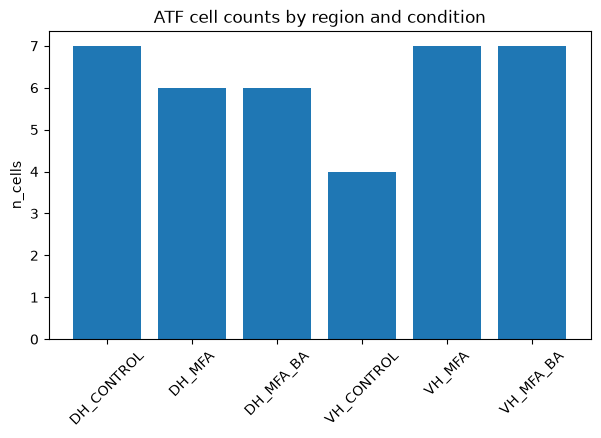

In [4]:
display(cell_counts)

fig, ax = plt.subplots(figsize=(7, 4))
plot_df = cell_counts.copy()
plot_df["label"] = plot_df["region"] + "_" + plot_df["condition"]
ax.bar(plot_df["label"], plot_df["n_cells"])
ax.set_ylabel("n_cells")
ax.set_title("ATF cell counts by region and condition")
ax.tick_params(axis="x", rotation=45)
plt.show()

## Canonical sweep-level feature table

In [5]:
feature_view = feature_df[
    [
        "file_id",
        "region",
        "condition",
        "sweep",
        "peak_depolarization_mV",
        "stim_end_depolarization_mV",
        "rise_slope_mV_per_s",
        "rise_tau_s",
        "plateau_slope_mV_per_s",
        "decay_slope_mV_per_s",
        "decay_tau_s",
        "undershoot_magnitude_mV",
        "return_slope_mV_per_s",
        "n_artifact_points_total",
    ]
].copy()
print(feature_view.round(4).to_string(index=False))

       file_id region condition  sweep  peak_depolarization_mV  stim_end_depolarization_mV  rise_slope_mV_per_s  rise_tau_s  plateau_slope_mV_per_s  decay_slope_mV_per_s  decay_tau_s  undershoot_magnitude_mV  return_slope_mV_per_s  n_artifact_points_total
1_DH_1_CONTROL     DH   CONTROL      1                  7.2864                      6.7444               8.9886      0.2451                 -0.0340               10.6624       0.2732                   1.3220                 0.0323                        0
1_DH_1_CONTROL     DH   CONTROL      2                 10.6458                      9.9183              14.0461      0.2348                 -0.0318               14.5677       0.2906                   1.9103                 0.0411                        0
1_DH_1_CONTROL     DH   CONTROL      3                 14.0393                     13.2752              19.7089      0.2145                 -0.0108               18.4372       0.2857                   2.3144                 0.0476  

## Redundancy diagnostics

In [6]:
print(redundancy.round(4).to_string(index=False))

                 feature_a                  feature_b  n_complete_pairs  pearson_r  spearman_r  abs_spearman_r  redundant_flag
    peak_depolarization_mV stim_end_depolarization_mV               222     0.9986      0.9984          0.9984            True
       rise_slope_mV_per_s                 rise_tau_s               222    -0.6653     -0.9251          0.9251           False
       rise_slope_mV_per_s       decay_slope_mV_per_s               222     0.9196      0.8891          0.8891           False
                rise_tau_s       decay_slope_mV_per_s               222    -0.5775     -0.8253          0.8253           False
                rise_tau_s    undershoot_magnitude_mV               222    -0.6434     -0.8180          0.8180           False
      decay_slope_mV_per_s    undershoot_magnitude_mV               222     0.7795      0.7787          0.7787           False
       rise_slope_mV_per_s    undershoot_magnitude_mV               222     0.8231      0.7759          0.7759 

## Condition-level feature reliability

In [7]:
print(condition_reliability.round(4).to_string(index=False))

condition                    feature  n_regions  mean_missing_rate  mean_completeness  mean_reliability_weight  any_small_stratum
  CONTROL       decay_slope_mV_per_s          2             0.0000             1.0000                   0.9000               True
  CONTROL                decay_tau_s          2             0.0000             1.0000                   0.9000               True
  CONTROL     peak_depolarization_mV          2             0.0000             1.0000                   0.4500               True
  CONTROL     plateau_slope_mV_per_s          2             0.0000             1.0000                   0.9000               True
  CONTROL      return_slope_mV_per_s          2             0.0774             0.9226                   0.8310               True
  CONTROL        rise_slope_mV_per_s          2             0.0000             1.0000                   0.9000               True
  CONTROL                 rise_tau_s          2             0.0000             1.0000     

## Region-specific feature reliability

In [8]:
print(reliability.round(4).to_string(index=False))

region condition                    feature  n_rows  n_cells  n_non_missing  missing_rate  completeness  max_abs_spearman  redundant_flag  small_stratum  reliability_weight
    DH   CONTROL       decay_slope_mV_per_s      42        7             42        0.0000        1.0000            0.8891           False          False              1.0000
    DH   CONTROL                decay_tau_s      42        7             42        0.0000        1.0000            0.7735           False          False              1.0000
    DH   CONTROL     peak_depolarization_mV      42        7             42        0.0000        1.0000            0.9984            True          False              0.5000
    DH   CONTROL     plateau_slope_mV_per_s      42        7             42        0.0000        1.0000            0.7360           False          False              1.0000
    DH   CONTROL      return_slope_mV_per_s      42        7             39        0.0714        0.9286            0.4825           Fal

## Region-aware thresholds

In [9]:
print(thresholds.round(4).to_string(index=False))

condition region  sweep                    feature  n_total_rows  n_non_missing  missing_rate  median      q1      q3     iqr  acceptable_lower  acceptable_upper threshold_scope  reliability_weight
  CONTROL     DH      1       decay_slope_mV_per_s             7              7        0.0000 10.6624  6.6801 11.7468  5.0667           -0.9200           19.3469 region_specific              1.0000
  CONTROL     DH      1                decay_tau_s             7              7        0.0000  0.2648  0.2296  0.3802  0.1507            0.0036            0.6062 region_specific              1.0000
  CONTROL     DH      1     peak_depolarization_mV             7              7        0.0000  7.6025  6.8372  7.8881  1.0509            5.2609            9.4644 region_specific              0.5000
  CONTROL     DH      1     plateau_slope_mV_per_s             7              7        0.0000 -0.0208 -0.0284  0.0006  0.0290           -0.0719            0.0441 region_specific              1.0000
  CONTROL 

## Region-effect summary

In [10]:
print(region_effects.round(4).to_string(index=False))

condition  sweep                    feature  n_dh  n_vh  median_dh  median_vh  vh_minus_dh_median  bootstrap_ci_low  bootstrap_ci_high  small_stratum
  CONTROL      1       decay_slope_mV_per_s     7     4    10.6624     5.8731             -4.7893           -6.6425             2.0408           True
  CONTROL      2       decay_slope_mV_per_s     7     4    14.5677     8.3477             -6.2200          -10.2377             2.9844           True
  CONTROL      3       decay_slope_mV_per_s     7     4    18.4372    11.5634             -6.8738          -12.3879             6.1643           True
  CONTROL      4       decay_slope_mV_per_s     7     4    22.5288    12.3095            -10.2193          -13.3983             4.6106           True
  CONTROL      5       decay_slope_mV_per_s     7     4    24.8577    15.3603             -9.4973          -14.7422             8.5924           True
  CONTROL      6       decay_slope_mV_per_s     7     4    27.3451    14.9625            -12.3827   

## Experimental perturbation direction targets

These tables convert ATF condition contrasts into signed direction targets for Step 06. The target directions are experimental guides for model perturbation response, not mechanism claims by themselves.


In [11]:
display(experimental_targets.head(40))
display(condition_contrasts.head(40))
assert {"CONTROL_to_MFA", "MFA_to_MFA_BA", "CONTROL_to_MFA_BA"}.issubset(set(experimental_targets["experimental_contrast"]))


,scope,region,experimental_contrast,feature,estimate,experimental_direction,n_sweeps,n_obs,min_qvalue_bh
54,region_blind,ALL,CONTROL_to_MFA,decay_slope_mV_per_s,-7.401744,decrease,6,144,1.200617e-02
55,region_blind,ALL,CONTROL_to_MFA,decay_tau_s,0.412724,increase,6,144,2.922640e-03
56,region_blind,ALL,CONTROL_to_MFA,peak_depolarization_mV,2.125131,no_clear_change,6,144,1.541461e-01
57,region_blind,ALL,CONTROL_to_MFA,plateau_slope_mV_per_s,0.027738,no_clear_change,6,144,4.464628e-02
58,region_blind,ALL,CONTROL_to_MFA,return_slope_mV_per_s,-0.004749,no_clear_change,6,122,1.142346e-01
59,region_blind,ALL,CONTROL_to_MFA,rise_slope_mV_per_s,-8.072455,decrease,6,144,8.365255e-03
60,region_blind,ALL,CONTROL_to_MFA,rise_tau_s,0.332634,increase,6,144,1.207750e-03
61,region_blind,ALL,CONTROL_to_MFA,stim_end_depolarization_mV,2.319206,no_clear_change,6,144,1.366514e-01
62,region_blind,ALL,CONTROL_to_MFA,undershoot_magnitude_mV,-0.671725,no_clear_change,6,144,2.217500e-02
63,region_blind,ALL,CONTROL_to_MFA_BA,decay_slope_mV_per_s,-11.704079,decrease,6,144,1.120164e-03


,scope,region,sweep,feature,experimental_contrast,cond_1,cond_2,mean_cond_1,mean_cond_2,ci_low_cond_1,ci_high_cond_1,ci_low_cond_2,ci_high_cond_2,estimate,pvalue,n_cond_1,n_cond_2,n_files,experimental_direction_raw,qvalue_bh,reject_bh_0p05,experimental_direction
0,region_DH,DH,1,decay_slope_mV_per_s,CONTROL_to_MFA,CONTROL,MFA,9.119879,4.348748,5.356206,12.883552,2.307269,6.390228,-4.771130,0.022549,7,6,13,decrease,0.042612,True,decrease
1,region_DH,DH,2,decay_slope_mV_per_s,CONTROL_to_MFA,CONTROL,MFA,12.750709,6.623817,7.468608,18.032811,3.311548,9.936087,-6.126892,0.036016,7,6,13,decrease,0.060447,False,no_clear_change
2,region_DH,DH,3,decay_slope_mV_per_s,CONTROL_to_MFA,CONTROL,MFA,16.243737,8.406027,8.309975,24.177500,4.017933,12.794121,-7.837710,0.061255,7,6,13,decrease,0.095774,False,no_clear_change
3,region_DH,DH,4,decay_slope_mV_per_s,CONTROL_to_MFA,CONTROL,MFA,18.668427,8.997645,10.404691,26.932163,4.567705,13.427584,-9.670782,0.031658,7,6,13,decrease,0.055663,False,no_clear_change
4,region_DH,DH,5,decay_slope_mV_per_s,CONTROL_to_MFA,CONTROL,MFA,21.097816,10.019204,11.108532,31.087101,5.198311,14.840097,-11.078612,0.037748,7,6,13,decrease,0.062829,False,no_clear_change
5,region_DH,DH,6,decay_slope_mV_per_s,CONTROL_to_MFA,CONTROL,MFA,21.542552,10.596047,11.743158,31.341946,5.466349,15.725745,-10.946505,0.037828,7,6,13,decrease,0.062829,False,no_clear_change
6,region_DH,DH,1,decay_tau_s,CONTROL_to_MFA,CONTROL,MFA,0.338588,0.787722,0.168150,0.509027,0.332623,1.242821,0.449133,0.052797,7,6,13,increase,0.083182,False,no_clear_change
7,region_DH,DH,2,decay_tau_s,CONTROL_to_MFA,CONTROL,MFA,0.356612,0.827747,0.163769,0.549455,0.286776,1.368718,0.471135,0.077994,7,6,13,increase,0.117358,False,no_clear_change
8,region_DH,DH,3,decay_tau_s,CONTROL_to_MFA,CONTROL,MFA,0.369792,0.854892,0.145595,0.593988,0.270263,1.439521,0.485100,0.090811,7,6,13,increase,0.132490,False,no_clear_change
9,region_DH,DH,4,decay_tau_s,CONTROL_to_MFA,CONTROL,MFA,0.388332,0.909512,0.178484,0.598179,0.318840,1.500185,0.521181,0.074966,7,6,13,increase,0.113514,False,no_clear_change


## DH/VH regional perturbation differences

The second-layer outputs quantify how DH and VH differ in their response to MFA and MFA+BA. Step 06 uses these as regional response-direction targets when comparing mechanistic classes.


In [12]:
display(regional_targets.head(40))
display(profile_terms.head(40))
second_layer_tables = {path.name: pd.read_csv(path) for path in sorted(second_layer_dir.glob("*.csv"))}
pd.DataFrame([
    {"table": name, "n_rows": len(table), "n_columns": len(table.columns)}
    for name, table in second_layer_tables.items()
]).sort_values("table")


,scope,region,experimental_contrast,feature,estimate,experimental_direction,n_sweeps,n_obs,min_qvalue_bh
0,delta_of_delta_DH_minus_VH,DH_minus_VH,CONTROL_to_MFA,decay_slope_mV_per_s,-4.088303,decrease,6,144,NaN
1,delta_of_delta_DH_minus_VH,DH_minus_VH,CONTROL_to_MFA,decay_tau_s,0.179198,increase,6,144,NaN
2,delta_of_delta_DH_minus_VH,DH_minus_VH,CONTROL_to_MFA,peak_depolarization_mV,4.804573,increase,6,144,NaN
3,delta_of_delta_DH_minus_VH,DH_minus_VH,CONTROL_to_MFA,plateau_slope_mV_per_s,0.000290,no_clear_change,6,144,NaN
4,delta_of_delta_DH_minus_VH,DH_minus_VH,CONTROL_to_MFA,return_slope_mV_per_s,0.020236,no_clear_change,6,122,NaN
5,delta_of_delta_DH_minus_VH,DH_minus_VH,CONTROL_to_MFA,rise_slope_mV_per_s,-3.435610,decrease,6,144,NaN
6,delta_of_delta_DH_minus_VH,DH_minus_VH,CONTROL_to_MFA,rise_tau_s,0.044960,increase,6,144,NaN
7,delta_of_delta_DH_minus_VH,DH_minus_VH,CONTROL_to_MFA,stim_end_depolarization_mV,4.570657,increase,6,144,NaN
8,delta_of_delta_DH_minus_VH,DH_minus_VH,CONTROL_to_MFA,undershoot_magnitude_mV,-0.314208,no_clear_change,6,144,NaN
9,delta_of_delta_DH_minus_VH,DH_minus_VH,CONTROL_to_MFA_BA,decay_slope_mV_per_s,-2.861044,decrease,6,144,NaN


,family,feature,term,scope,sweep,experimental_contrast,estimate,pvalue,qvalue_bh,reject_bh_0p05,experimental_direction
0,primary_continuous,peak_depolarization_mV,C(region):C(condition),matched_sweep_delta_of_delta,1,CONTROL_to_MFA,1.673875,NaN,NaN,False,increase
1,primary_continuous,stim_end_depolarization_mV,C(region):C(condition),matched_sweep_delta_of_delta,1,CONTROL_to_MFA,1.789127,NaN,NaN,False,increase
2,primary_continuous,rise_slope_mV_per_s,C(region):C(condition),matched_sweep_delta_of_delta,1,CONTROL_to_MFA,-1.814157,NaN,NaN,False,decrease
3,primary_continuous,rise_tau_s,C(region):C(condition),matched_sweep_delta_of_delta,1,CONTROL_to_MFA,0.124397,NaN,NaN,False,increase
4,primary_continuous,plateau_slope_mV_per_s,C(region):C(condition),matched_sweep_delta_of_delta,1,CONTROL_to_MFA,0.063011,NaN,NaN,False,increase
5,primary_continuous,decay_slope_mV_per_s,C(region):C(condition),matched_sweep_delta_of_delta,1,CONTROL_to_MFA,-2.493428,NaN,NaN,False,decrease
6,primary_continuous,decay_tau_s,C(region):C(condition),matched_sweep_delta_of_delta,1,CONTROL_to_MFA,0.062198,NaN,NaN,False,increase
7,primary_continuous,undershoot_magnitude_mV,C(region):C(condition),matched_sweep_delta_of_delta,1,CONTROL_to_MFA,-0.505954,NaN,NaN,False,decrease
8,primary_continuous,return_slope_mV_per_s,C(region):C(condition),matched_sweep_delta_of_delta,1,CONTROL_to_MFA,-0.023631,NaN,NaN,False,decrease
9,primary_continuous,peak_depolarization_mV,C(region):C(condition),matched_sweep_delta_of_delta,1,MFA_to_MFA_BA,0.757033,NaN,NaN,False,increase


,table,n_rows,n_columns
0,delta_feature_profiles_by_region.csv,36,15
1,delta_feature_profiles_region_blind.csv,18,15
2,matched_sweep_delta_of_delta.csv,162,18
3,numeric_sweep_combo_slopes.csv,54,9
4,numeric_sweep_condition_slope_deltas_within_re...,54,9
5,numeric_sweep_delta_of_delta_between_regions.csv,27,9
6,region_blind_condition_slope_deltas.csv,27,9
7,region_blind_condition_slopes.csv,27,8
8,region_perturbation_summary_selected_features.csv,9,8


## Consequence for later steps

Two practical conclusions stand out:

1. `peak_depolarization_mV` and `stim_end_depolarization_mV` are near-duplicates here and should not both dominate later losses.
2. `return_slope_mV_per_s` has condition-dependent missingness, so its weight should be explicitly moderated rather than treated as uniformly reliable across conditions.

## Post-execution scientific status

Executed status for reviewer response: Step 02 supports R2/R6/R7 by rebuilding full target-scope ATF feature tables and region-aware thresholds from 222 sweeps (37 cells x 6 currents). It now also exports condition-contrast direction targets, DH/VH delta-of-delta perturbation targets, region-blind trend summaries, delta-feature profiles, and region-condition profile terms. These outputs define the experimental kinetic alteration targets used by Step 06; they do not by themselves establish mechanism classes or degeneracy.
